In [1]:
# import libraries
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

/Users/ogbi/miniconda3/envs/poultry/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


In [2]:
# Load segmentation model
path = "/Users/ogbi/School/Research/poultry-vision/models/pen-seg-large.pt"
model = YOLO(path)


0: 384x640 1 feeder, 9 hens, 1 waterer, 361.9ms
Speed: 1.5ms preprocess, 361.9ms inference, 6.4ms postprocess per image at shape (1, 3, 384, 640)


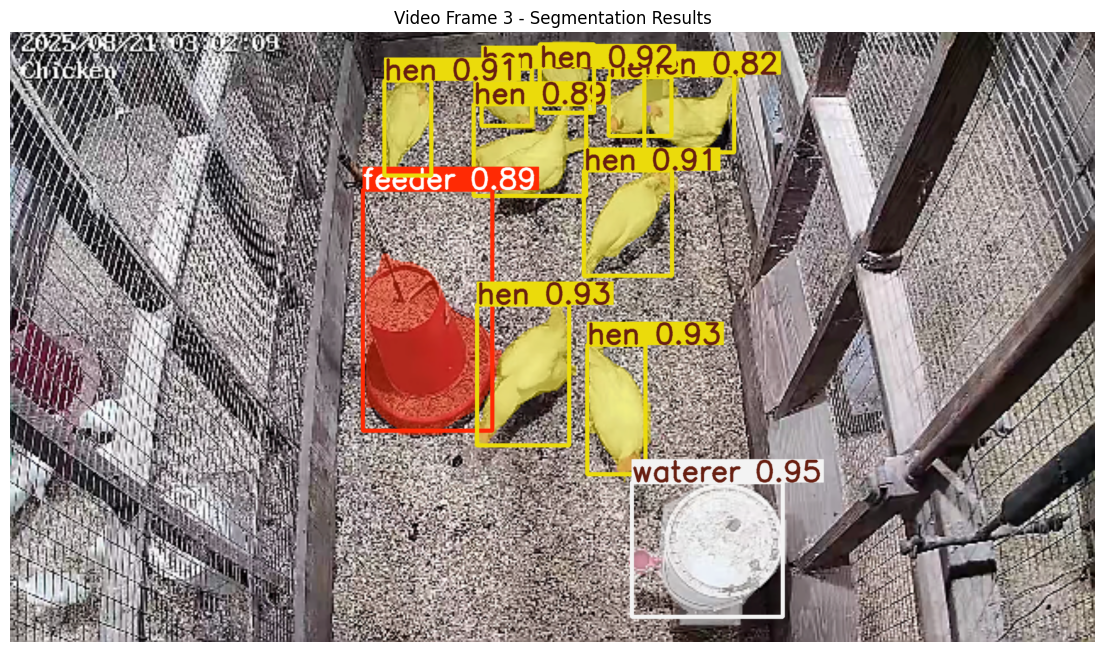

=== Identified Objects in Frame 3 ===

Object 1:
  Type: waterer
  Confidence: 0.9487
  Bounding Box: x1=1100.1, y1=797.5, x2=1367.2, y2=1035.9
  Size: 267.1 x 238.4 pixels
  Mask Area: 5154 pixels

Object 2:
  Type: hen
  Confidence: 0.9345
  Bounding Box: x1=1021.6, y1=554.8, x2=1124.4, y2=783.3
  Size: 102.8 x 228.4 pixels
  Mask Area: 1849 pixels

Object 3:
  Type: hen
  Confidence: 0.9301
  Bounding Box: x1=826.5, y1=483.7, x2=989.7, y2=733.0
  Size: 163.2 x 249.3 pixels
  Mask Area: 2129 pixels

Object 4:
  Type: hen
  Confidence: 0.9171
  Bounding Box: x1=937.6, y1=23.7, x2=1033.8, y2=144.3
  Size: 96.2 x 120.6 pixels
  Mask Area: 827 pixels

Object 5:
  Type: hen
  Confidence: 0.9120
  Bounding Box: x1=662.9, y1=87.6, x2=745.6, y2=255.7
  Size: 82.7 x 168.2 pixels
  Mask Area: 1045 pixels

Object 6:
  Type: hen
  Confidence: 0.9074
  Bounding Box: x1=1015.8, y1=246.5, x2=1171.3, y2=432.5
  Size: 155.5 x 186.0 pixels
  Mask Area: 1568 pixels

Object 7:
  Type: feeder
  Confidenc

In [3]:
# Extract 3rd frame from video and segment
video_path = "/Users/ogbi/School/Research/poultry-vision/samplevideos/poultry-vid-01.mp4"
cap = cv2.VideoCapture(video_path)

frame_num = 2
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Run segmentation model on the frame
    results = model(frame_rgb)
    result = results[0]
    
    # Display segmented frame
    segmented_image = result.plot()
    plt.figure(figsize=(14, 10))
    plt.imshow(segmented_image)
    plt.title("Video Frame 3 - Segmentation Results")
    plt.axis('off')
    plt.show()
    
    # Extract and display all identified objects
    print("=== Identified Objects in Frame 3 ===\n")
    if result.boxes is not None:
        for idx in range(len(result.boxes)):
            class_id = int(result.boxes.cls[idx])
            class_name = result.names[class_id]
            confidence = result.boxes.conf[idx].item()
            box = result.boxes.xyxy[idx].cpu().numpy()
            
            # Calculate mask area if available
            mask_area = 0
            if result.masks:
                mask_area = int(result.masks.data[idx].sum().item())
            
            print(f"Object {idx + 1}:")
            print(f"  Type: {class_name}")
            print(f"  Confidence: {confidence:.4f}")
            print(f"  Bounding Box: x1={box[0]:.1f}, y1={box[1]:.1f}, x2={box[2]:.1f}, y2={box[3]:.1f}")
            print(f"  Size: {box[2]-box[0]:.1f} x {box[3]-box[1]:.1f} pixels")
            print(f"  Mask Area: {mask_area} pixels\n")
    else:
        print("No objects detected in this frame")
else:
    print("Failed to read frame from video")


0: 384x640 11 hens, 2 waterers, 336.6ms
Speed: 1.0ms preprocess, 336.6ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)


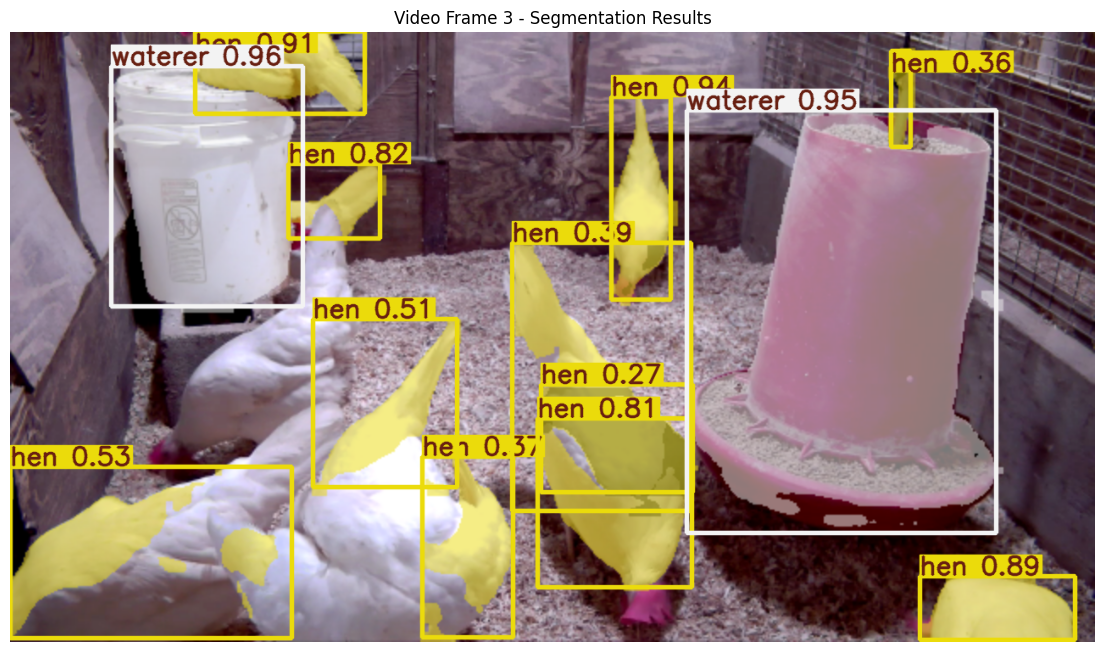

=== Identified Objects in Frame 3 ===

Object 1:
  Type: waterer
  Confidence: 0.9628
  Bounding Box: x1=119.1, y1=41.5, x2=345.9, y2=324.5
  Size: 226.8 x 283.0 pixels
  Mask Area: 12420 pixels

Object 2:
  Type: waterer
  Confidence: 0.9489
  Bounding Box: x1=798.2, y1=93.1, x2=1163.3, y2=591.2
  Size: 365.1 x 498.2 pixels
  Mask Area: 29796 pixels

Object 3:
  Type: hen
  Confidence: 0.9411
  Bounding Box: x1=709.1, y1=77.4, x2=779.1, y2=316.6
  Size: 70.0 x 239.2 pixels
  Mask Area: 2638 pixels

Object 4:
  Type: hen
  Confidence: 0.9082
  Bounding Box: x1=218.4, y1=0.0, x2=418.5, y2=97.4
  Size: 200.1 x 97.4 pixels
  Mask Area: 3526 pixels

Object 5:
  Type: hen
  Confidence: 0.8896
  Bounding Box: x1=1073.5, y1=642.6, x2=1256.1, y2=717.4
  Size: 182.6 x 74.8 pixels
  Mask Area: 3115 pixels

Object 6:
  Type: hen
  Confidence: 0.8213
  Bounding Box: x1=328.7, y1=156.2, x2=437.0, y2=245.0
  Size: 108.3 x 88.7 pixels
  Mask Area: 1053 pixels

Object 7:
  Type: hen
  Confidence: 0.80

In [10]:
# Extract 3rd frame from video and segment
video_path = "/Users/ogbi/School/Research/poultry-vision/samplevideos/cam_low_20251218_150124.mp4"
cap = cv2.VideoCapture(video_path)

frame_num = 80
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Run segmentation model on the frame
    results = model(frame_rgb)
    result = results[0]
    
    # Display segmented frame
    segmented_image = result.plot()
    plt.figure(figsize=(14, 10))
    plt.imshow(segmented_image)
    plt.title("Video Frame 3 - Segmentation Results")
    plt.axis('off')
    plt.show()
    
    # Extract and display all identified objects
    print("=== Identified Objects in Frame 3 ===\n")
    if result.boxes is not None:
        for idx in range(len(result.boxes)):
            class_id = int(result.boxes.cls[idx])
            class_name = result.names[class_id]
            confidence = result.boxes.conf[idx].item()
            box = result.boxes.xyxy[idx].cpu().numpy()
            
            # Calculate mask area if available
            mask_area = 0
            if result.masks:
                mask_area = int(result.masks.data[idx].sum().item())
            
            print(f"Object {idx + 1}:")
            print(f"  Type: {class_name}")
            print(f"  Confidence: {confidence:.4f}")
            print(f"  Bounding Box: x1={box[0]:.1f}, y1={box[1]:.1f}, x2={box[2]:.1f}, y2={box[3]:.1f}")
            print(f"  Size: {box[2]-box[0]:.1f} x {box[3]-box[1]:.1f} pixels")
            print(f"  Mask Area: {mask_area} pixels\n")
    else:
        print("No objects detected in this frame")
else:
    print("Failed to read frame from video")

In [7]:
import os
import numpy as np

# Create directory to save mask-based crops
crop_dir = "/Users/ogbi/School/Research/poultry-vision/segmentation_crops/frame_3"
os.makedirs(crop_dir, exist_ok=True)

# Save mask-based crops of all detected instances with no background
if ret and result.masks is not None:
    orig_h, orig_w = frame_rgb.shape[:2]
    mask_h, mask_w = result.masks.data.shape[1], result.masks.data.shape[2]
    print(f"Original frame size: {orig_w}x{orig_h}")
    print(f"Mask tensor size: {mask_w}x{mask_h}")
    print(f"=== Saving Mask-based Segmentation Crops (No Background) to {crop_dir} ===\n")
    
    for idx in range(len(result.masks)):
        class_id = int(result.boxes.cls[idx])
        class_name = result.names[class_id]
        confidence = result.boxes.conf[idx].item()
        
        # Get the mask at model resolution and resize to original frame size
        mask_raw = result.masks.data[idx].cpu().numpy()
        mask_resized = cv2.resize(mask_raw, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
        mask_binary = (mask_resized > 0.5).astype(np.uint8)
        
        # Find bounding box of the mask in original image coordinates
        y_coords, x_coords = np.where(mask_binary > 0)
        
        if len(y_coords) > 0:
            x_min, x_max = x_coords.min(), x_coords.max() + 1
            y_min, y_max = y_coords.min(), y_coords.max() + 1
            
            # Add small padding
            padding = 5
            x_min = max(0, x_min - padding)
            y_min = max(0, y_min - padding)
            x_max = min(orig_w, x_max + padding)
            y_max = min(orig_h, y_max + padding)
            
            # Crop both image and resized mask to the same bounds
            crop = frame_rgb[y_min:y_max, x_min:x_max].copy()
            mask_crop = mask_binary[y_min:y_max, x_min:x_max]
            
            # Create white background and paste only masked pixels
            result_crop = np.full_like(crop, 255, dtype=np.uint8)
            result_crop[mask_crop == 1] = crop[mask_crop == 1]
            
            # Save as PNG to preserve clean edges
            filename = f"{class_name}_{idx:02d}_{confidence:.2f}.png"
            filepath = os.path.join(crop_dir, filename)
            crop_bgr = cv2.cvtColor(result_crop, cv2.COLOR_RGB2BGR)
            cv2.imwrite(filepath, crop_bgr)
            
            print(f"Saved: {filename}")
            print(f"  Crop size: {result_crop.shape[1]} x {result_crop.shape[0]} pixels")
            print(f"  Masked pixels: {mask_crop.sum()}\n")
    
    print(f"Total mask-based crops saved: {len(result.masks)}")
else:
    print("No masks available to crop")

Original frame size: 1920x1080
Mask tensor size: 640x384
=== Saving Mask-based Segmentation Crops (No Background) to /Users/ogbi/School/Research/poultry-vision/segmentation_crops/frame_3 ===

Saved: waterer_00_0.95.png
  Crop size: 286 x 246 pixels
  Masked pixels: 43452

Saved: hen_01_0.93.png
  Crop size: 118 x 235 pixels
  Masked pixels: 15587

Saved: hen_02_0.93.png
  Crop size: 190 x 244 pixels
  Masked pixels: 17962

Saved: hen_03_0.92.png
  Crop size: 103 x 131 pixels
  Masked pixels: 6957

Saved: hen_04_0.91.png
  Crop size: 91 x 168 pixels
  Masked pixels: 8827

Saved: hen_05_0.91.png
  Crop size: 178 x 190 pixels
  Masked pixels: 13242

Saved: feeder_06_0.89.png
  Crop size: 250 x 311 pixels
  Masked pixels: 50668

Saved: hen_07_0.89.png
  Crop size: 214 x 167 pixels
  Masked pixels: 16062

Saved: hen_08_0.87.png
  Crop size: 106 x 111 pixels
  Masked pixels: 7502

Saved: hen_09_0.82.png
  Crop size: 178 x 145 pixels
  Masked pixels: 13593

Saved: hen_10_0.79.png
  Crop size: